In [48]:
import pandas as pd
import numpy as np

df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [49]:
# AT => temperature
# v => vaccume
# AP => pressure
# RH => humidity
# PE => produced energy

df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [50]:
X = df.drop("PE", axis=1)
y = df["PE"]

y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [51]:
# Split out Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

df.shape

(9568, 5)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

X_test_scaler

array([[ 1.04271077,  1.1677481 , -2.00565355,  0.61698162],
       [ 0.30987852,  0.25321117,  0.2377912 ,  0.34699369],
       [ 0.83735668,  0.23905669, -0.19937552, -2.00361006],
       ...,
       [ 0.13539466, -0.39868144,  0.27506898, -1.02345136],
       [ 0.48973112,  0.51585549,  0.79187461, -0.40623845],
       [ 1.21719463,  1.36512452, -1.03812564, -0.24561272]],
      shape=(1914, 4))

In [53]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaler, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaler, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [54]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning

In [55]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1),

        )

    def forward(self, x):
        return self.model(x)

In [56]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [57]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of batch
        optimizer.zero_grad()

        output = model(xb) # predicted outputs for this batch
        loss = crietrion(output, yb) # compute loss
        loss.backward() # bck propagation compute gradients
        optimizer.step() # updates parameters

        running_loss += loss.item() # loss is a tensor value converting to python float value

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            output = model(xb)
            loss = crietrion(output, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss: {epoch_train_loss} & val loss = {epoch_val_loss}")


    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model_demo.pth")

epoch 1/100 ==> train loss: 205658.6744140625 & val loss = 203110.88098958333
epoch 2/100 ==> train loss: 195323.50390625 & val loss = 182435.89348958334
epoch 3/100 ==> train loss: 163819.4575846354 & val loss = 140312.695703125
epoch 4/100 ==> train loss: 119414.91396484376 & val loss = 96169.63736979167
epoch 5/100 ==> train loss: 82177.67918294271 & val loss = 65541.9939453125
epoch 6/100 ==> train loss: 51463.396752929686 & val loss = 35605.09296875
epoch 7/100 ==> train loss: 25545.715751139323 & val loss = 16970.644108072916
epoch 8/100 ==> train loss: 12512.085845947266 & val loss = 9739.667635091146
epoch 9/100 ==> train loss: 7758.842366536458 & val loss = 6854.677571614583
epoch 10/100 ==> train loss: 5518.484942626953 & val loss = 4960.022961425781
epoch 11/100 ==> train loss: 3982.434339396159 & val loss = 3542.734452311198
epoch 12/100 ==> train loss: 2811.372447713216 & val loss = 2486.77671101888
epoch 13/100 ==> train loss: 1969.5436144510904 & val loss = 1732.42936503

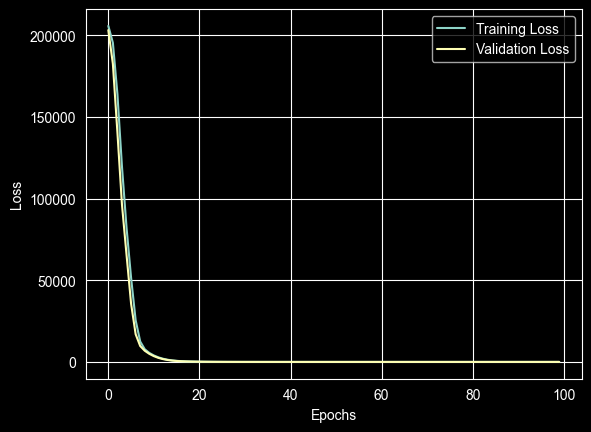

In [58]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [59]:
# loading the best model

model.load_state_dict(torch.load("best_model_demo.pth"))

<All keys matched successfully>

In [61]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Validation MSE:", test_mse_loss.item())

Training MSE: 19.86250877380371
Validation MSE: 18.830894470214844


In [62]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_train_tensor, train_preds))

R2 Score: 0.9319656491279602


In [67]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted,Actual Values
0,433.082245,426.18
1,448.055420,451.10
2,444.392181,442.87
3,445.504242,443.70
4,461.806488,460.59
...,...,...
1909,467.278229,468.19
1910,431.853668,431.16
1911,455.227386,454.20
1912,446.044281,444.13
